In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

In [3]:
null_columns_a = ["life_expectancy", "adult_mortality", "bmi", "polio", "diphtheria", "thinness_10_19_years", "thinness_5_9_years"]
drop_columns = [col for col in null_columns_a if col] # Derived from null_columns_a to remove rows with null values less than 5%
null_columns_b = ["alcohol", "hepatitis_b", "total_expenditure", "gdp", "population", "schooling", "income_composition_of_resources"]
imp_cols = [col for col in null_columns_b if col]
imp_mean_col = ["alcohol", "total_expenditure", "gdp", "population", "income_composition_of_resources"]
imp_median_col = ["hepatitis_b", "schooling"]


In [49]:
data = (
    pd.read_csv("life_expectancy_data.csv")
    .rename(columns= lambda col: col.strip().lower().replace(" ", "_").replace("-", "_").replace("thinness_1_19_years", "thinness_10_19_years"))
    .dropna(subset = drop_columns, how = "any")
    .assign(avg_thinness = lambda x : x[["thinness_10_19_years", "thinness_5_9_years"]].mean(axis = 1))
    .drop(columns = ["infant_deaths", "country", "thinness_10_19_years", "thinness_5_9_years"]) #Feature Engineering
)
pd.set_option("display.max_columns", None)
data

,year,status,life_expectancy,adult_mortality,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,income_composition_of_resources,schooling,avg_thinness
0,2015,Developing,65.0,263.0,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,0.479,10.1,17.25
1,2014,Developing,59.9,271.0,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,0.476,10.0,17.50
2,2013,Developing,59.9,268.0,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,0.470,9.9,17.70
3,2012,Developing,59.5,272.0,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,0.463,9.8,17.95
4,2011,Developing,59.2,275.0,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,0.454,9.5,18.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,Developing,44.3,723.0,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,0.407,9.2,9.40
2934,2003,Developing,44.5,715.0,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,0.418,9.5,9.85
2935,2002,Developing,44.8,73.0,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,0.427,10.0,1.25
2936,2001,Developing,45.3,686.0,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,0.427,9.8,1.65


In [5]:
missing_data = data.isnull().sum()
total_obv = data.shape[0]
print(f"Total Sum of Missing Data: {missing_data}")
print(f"Total Number of Observations/Rows:{total_obv}")

Total Sum of Missing Data: year                                 0
status                               0
life_expectancy                      0
adult_mortality                      0
alcohol                            175
percentage_expenditure               0
hepatitis_b                        525
measles                              0
bmi                                  0
under_five_deaths                    0
polio                                0
total_expenditure                  212
diphtheria                           0
hiv/aids                             0
gdp                                435
population                         644
income_composition_of_resources    160
schooling                          160
avg_thinness                         0
dtype: int64
Total Number of Observations/Rows:2888


In [6]:
missing_percent = missing_data / total_obv * 100
missing_percent

year                                0.000000
status                              0.000000
life_expectancy                     0.000000
adult_mortality                     0.000000
alcohol                             6.059557
percentage_expenditure              0.000000
hepatitis_b                        18.178670
measles                             0.000000
bmi                                 0.000000
under_five_deaths                   0.000000
polio                               0.000000
total_expenditure                   7.340720
diphtheria                          0.000000
hiv/aids                            0.000000
gdp                                15.062327
population                         22.299169
income_composition_of_resources     5.540166
schooling                           5.540166
avg_thinness                        0.000000
dtype: float64

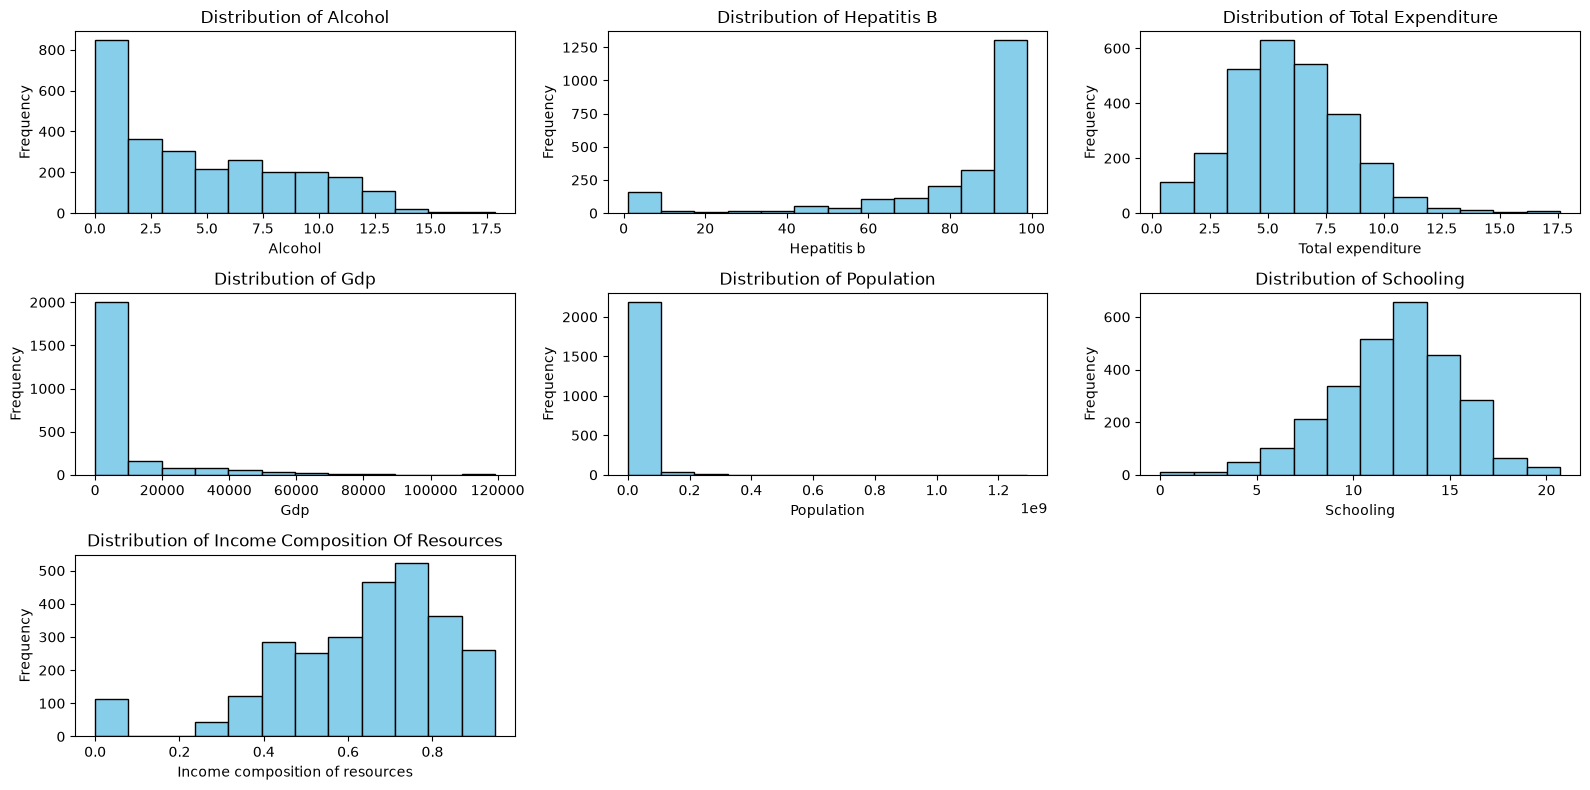

In [7]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (16, 8))
axes = axes.flatten()
for i, col in enumerate(imp_cols):
    axes[i].hist(data[col], bins = 12
    , color = "skyblue", edgecolor = "black")
    axes[i].set_title(f"Distribution of {col.capitalize().replace("_", " ").title()}")
    axes[i].set_xlabel(col.capitalize().replace("_", " "))
    axes[i].set_ylabel("Frequency")
for j in range(len(imp_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()    

In [8]:
for col in imp_mean_col:
    mean_val = data[col].mean()
    data[col] = data[col].fillna(mean_val)  

for col in imp_median_col:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val) 

In [9]:
num_columns = data.select_dtypes("number")
corr_matrix_cols = (
    num_columns.corr()
)
corr_mask = np.triu(np.ones_like(corr_matrix_cols, dtype = bool))
masked_corr_matrix = corr_matrix_cols.mask(corr_mask)

cleaned_corr_matrix = (
    masked_corr_matrix.unstack()
    .dropna()
    .reset_index()
)
cleaned_corr_matrix.columns = ["Metric 1", "Metric 2", "Correlation"]
cleaned_corr_matrix["Abs_Corr"] = cleaned_corr_matrix["Correlation"].abs()
cleaned_corr_matrix = cleaned_corr_matrix.sort_values(by = "Abs_Corr", ascending = True).drop(columns = ["Abs_Corr"]).reset_index(drop = True)
cleaned_corr_matrix

,Metric 1,Metric 2,Correlation
0,total_expenditure,hiv/aids,0.000392
1,population,income_composition_of_resources,-0.011185
2,adult_mortality,population,-0.011809
3,year,population,0.014036
4,life_expectancy,population,-0.020842
...,...,...,...
148,life_expectancy,income_composition_of_resources,0.693177
149,life_expectancy,adult_mortality,-0.693189
150,life_expectancy,schooling,0.724434
151,income_composition_of_resources,schooling,0.787395


<Axes: >

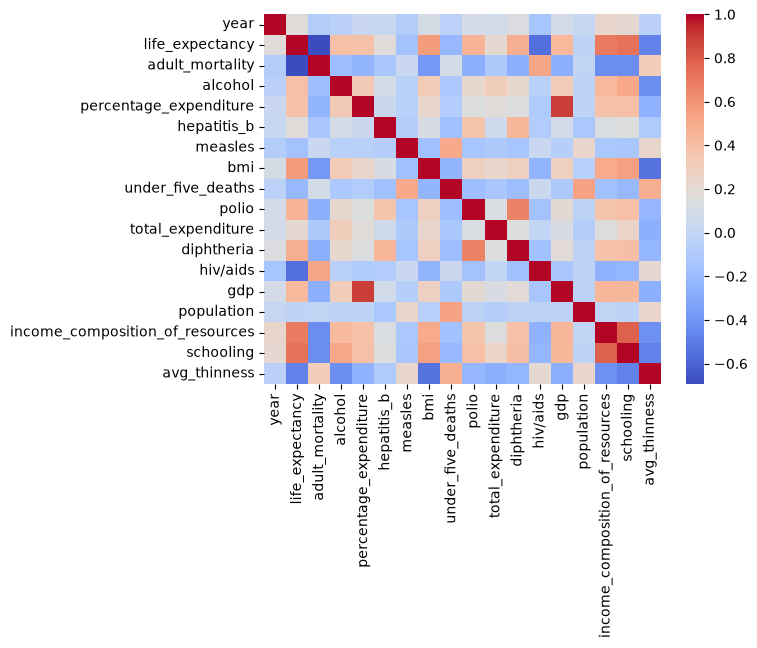

In [10]:
sns.heatmap(data.corr(numeric_only = True), annot = False, cmap = "coolwarm")

In [11]:
target_var = "life_expectancy"
target_corr = (
    cleaned_corr_matrix[(cleaned_corr_matrix["Metric 1"] == target_var) | (cleaned_corr_matrix["Metric 2"] == target_var)]
    .copy()
    .sort_values(ascending = False, by = "Correlation", key = abs)
    .reset_index(drop = True)
)

target_corr 

,Metric 1,Metric 2,Correlation
0,life_expectancy,schooling,0.724434
1,life_expectancy,adult_mortality,-0.693189
2,life_expectancy,income_composition_of_resources,0.693177
3,life_expectancy,bmi,0.567055
4,life_expectancy,hiv/aids,-0.560382
5,life_expectancy,avg_thinness,-0.480929
6,life_expectancy,diphtheria,0.478194
7,life_expectancy,polio,0.464166
8,life_expectancy,gdp,0.431241
9,life_expectancy,alcohol,0.394527


In [12]:
target = "life_expectancy"
features = [col for col in data.columns if col not in target]
X = data[features]
y = data[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 2310
Test set: 578


In [34]:
#Baseline Mean
target_mean = y_train.mean()
target_pred_baseline = [target_mean] * len(y_test)
baseline_mean = mean_absolute_error(y_test, target_pred_baseline)

#Linear Regressiion Model and OnHotEncoder to encode status
model_lr = make_pipeline(
    OneHotEncoder(drop = "first", handle_unknown = "ignore"),
    LinearRegression()
)

#Fit the Model on Train Dataset
model_lr.fit(X_train, y_train)
target_pred_on_train = model_lr.predict(X_train)

#Generating Predictions Using Train Dataset
mae_train = mean_absolute_error(y_train, target_pred_on_train)
rmse_train = root_mean_squared_error(y_train, target_pred_on_train)
r2_train = r2_score(y_train, target_pred_on_train)

print(f"Baseline Mean: {baseline_mean:.2f}")
print(f"Train Mean Absolute Error: {mae_train:.4f}")
print(f"Train Root Mean Squared Eror: {rmse_train:.4f}")
print(f"Train R Squared: {r2_train:.4f}")

#Pedict on Test Dataset
target_pred_on_test = model_lr.predict(X_test)

#Generating Predictions Using Test Dataset
mae_test = mean_absolute_error(y_test, target_pred_on_test)
rmse_test = root_mean_squared_error(y_test, target_pred_on_test)
r2_test = r2_score(y_test, target_pred_on_test)

print(f"Test Mean Absolute Error: {mae_test:.4f}")
print(f"Test Root Mean Squared Eror: {rmse_test:.4f}")
print(f"Test R Squared: {r2_test:.4f}")
print(f"The difference between train and test RMSE for Linear Regression is: {rmse_test - rmse_train:.4f}")

Baseline Mean: 7.74
Train Mean Absolute Error: 0.0001
Train Root Mean Squared Eror: 0.0002
Train R Squared: 1.0000
Test Mean Absolute Error: 3.5409
Test Root Mean Squared Eror: 4.7783
Test R Squared: 0.7471
The difference between train and test RMSE for Linear Regression is: 4.7781


c:\Users\HP\Desktop\Data Science\project_life_expectancy\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [36]:
#Preventing Overfitting with Ridge/L2 Penalty
ridge_model = make_pipeline(
    OneHotEncoder(drop = "first", handle_unknown = "ignore"),
    StandardScaler(with_mean = False),
    Ridge(alpha = 1.0)
)
ridge_model.fit(X_train, y_train)
target_pred_on_train_ridge = ridge_model.predict(X_train)
#Generating Predictions Using Train Dataset
mae_train_ridge = mean_absolute_error(y_train, target_pred_on_train_ridge)
rmse_train_ridge = root_mean_squared_error(y_train, target_pred_on_train_ridge)
r2_train_ridge = r2_score(y_train, target_pred_on_train_ridge)

print(f"Baseline Mean: {baseline_mean:.2f}")
print(f"Ridge Train Mean Absolute Error: {mae_train_ridge:.4f}")
print(f"Ridge Train Root Mean Squared Eror: {rmse_train_ridge:.4f}")
print(f"Ridge Train R Squared: {r2_train_ridge:.4f}")

#Pedict on Test Dataset With L2 Penalty
target_pred_on_test_ridge = ridge_model.predict(X_test)

#Generating Predictions Using Test Dataset
mae_test_ridge = mean_absolute_error(y_test, target_pred_on_test_ridge)
rmse_test_ridge = root_mean_squared_error(y_test, target_pred_on_test_ridge)
r2_test_ridge = r2_score(y_test, target_pred_on_test_ridge)

print(f"Ridge Test Mean Absolute Error: {mae_test:.4f}")
print(f"Ridge Test Root Mean Squared Eror: {rmse_test:.4f}")
print(f"Ridge Test R Squared: {r2_test:.4f}")

Baseline Mean: 7.74
Ridge Train Mean Absolute Error: 0.0007
Ridge Train Root Mean Squared Eror: 0.0011
Ridge Train R Squared: 1.0000
Ridge Test Mean Absolute Error: 3.5409
Ridge Test Root Mean Squared Eror: 4.7783
Ridge Test R Squared: 0.7471


c:\Users\HP\Desktop\Data Science\project_life_expectancy\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [39]:
#Preventing Overfitting with Lasso/L1 Penalty
lasso_model = make_pipeline(
    OneHotEncoder(drop = "first", handle_unknown = "ignore"),
    StandardScaler(with_mean = False),
    Lasso(alpha = 100, max_iter = 10000)
)
lasso_model.fit(X_train, y_train)
target_pred_on_train_lasso = lasso_model.predict(X_train)
#Generating Predictions Using Train Dataset
mae_train_lasso = mean_absolute_error(y_train, target_pred_on_train_lasso)
rmse_train_lasso = root_mean_squared_error(y_train, target_pred_on_train_lasso)
r2_train_lasso = r2_score(y_train, target_pred_on_train_lasso)

print(f"Baseline Mean: {baseline_mean:.2f}")
print(f"Ridge Train Mean Absolute Error: {mae_train_lasso:.4f}")
print(f"Ridge Train Root Mean Squared Eror: {rmse_train_lasso:.4f}")
print(f"Ridge Train R Squared: {r2_train_lasso:.4f}")

#Pedict on Test Dataset With L2 Penalty
target_pred_on_test_lasso = lasso_model.predict(X_test)

#Generating Predictions Using Test Dataset
mae_test_lasso = mean_absolute_error(y_test, target_pred_on_test_lasso)
rmse_test_lasso = root_mean_squared_error(y_test, target_pred_on_test_lasso)
r2_test_lasso = r2_score(y_test, target_pred_on_test_lasso)

print(f"Lasso Test Mean Absolute Error: {mae_test:.4f}")
print(f"Lasso Test Root Mean Squared Eror: {rmse_test:.4f}")
print(f"Lasso Test R Squared: {r2_test:.4f}")

Baseline Mean: 7.74
Ridge Train Mean Absolute Error: 7.7155
Ridge Train Root Mean Squared Eror: 9.4890
Ridge Train R Squared: 0.0000
Lasso Test Mean Absolute Error: 3.5409
Lasso Test Root Mean Squared Eror: 4.7783
Lasso Test R Squared: 0.7471


c:\Users\HP\Desktop\Data Science\project_life_expectancy\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [51]:
model_comp = pd.DataFrame(
    {
        "Model": ["Linear", "Ridge", "Lasso"],
        "Train MAE": [mae_train, mae_train_ridge, mae_train_lasso],
        "Test MAE": [mae_test, mae_test_ridge, mae_test_lasso],
        "Train RMSE": [rmse_train, rmse_train_ridge, rmse_train_lasso],
        "Test RMSE": [rmse_test, rmse_test_ridge, rmse_test_lasso],
        "Train R2": [r2_train, r2_train_ridge, r2_train_lasso],
        "Test R2": [r2_test, r2_test_ridge, r2_test_lasso],
    }
)
model_comp = model_comp.assign(RMSE_Diff = lambda x : x["Test RMSE"] - x["Train RMSE"])
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
print(model_comp)

    Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2   Test R2  RMSE_Diff
0  Linear   0.000141  3.540884    0.000203   4.778259       1.0  0.747071   4.778055
1   Ridge   0.000734  4.019178    0.001080   5.635234       1.0  0.648210   5.634154
2   Lasso   7.715460  7.737179    9.488954   9.516153       0.0 -0.003189   0.027199
